In [1]:
import sys
sys.path.append("/userdata/jgauthier/projects/EMU_data_collection/src/python")
sys.path.append("src")

In [73]:
import os
from pathlib import Path
from typing import Optional

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
from loguru import logger as L

In [3]:
%load_ext autoreload
%autoreload 2

In [20]:
from neuralynx_to_mne import epoch_ecog_mne
from viz import plot_epochs

In [5]:
# =============================================================================
# CONFIGURATION - Update these parameters for your analysis
# =============================================================================

# Patient and Block Configuration
PATIENT = "EC347"
NL_BLOCK = "B16"  # block name of the raw Neuralynx recording
BLOCK = "default"  # block name of the preprocessed block directory. Set to `default` will default to using `NL_BLOCK`.
MULTIPLE_RECORDINGS = False  # whether there are multiple recordings within this single Neuralynx `BLOCK`. Default to `False`.

if BLOCK == "default":
    BLOCK = NL_BLOCK

############
### If there are multiple recordings in a single Neuralynx "block", `BLOCK_IDX` indicates which one to preprocess. 
### Will use recording times from the events `.nev` file to select the chunk of raw data to use from the full recording.
### If this is a single block, set to `None`.
############
BLOCK_IDX = None

TASK = "dot-prediction"

# Path Configuration
RAW_ROOT = f"/data_store1/human/Neuralynx/{PATIENT}/{PATIENT}_{NL_BLOCK}"
SESSION_SUBDIR = os.listdir(RAW_ROOT)[0] ## need manual check
PREPROC_ROOT = f"/data_store1/human/Neuralynx_preproc/{PATIENT}/{PATIENT}_{BLOCK}"

# Processing Parameters
GRID_N_CH = 74
RUN_CAR = False ## run car or not
CAR_BSIZE = 16
DS_HZ = 1000 # Intermediate sampling rate (in Hz).
FINAL_HZ = 100
SUFFIX = ""  ## example: "0005"
EVENT_SUFFIX = ""  ## suffix for the `Events_XXXX.nev` file

# Optional: 3D Visualization (set to None to skip)
ANAT_ROOT = None  # or None

# ERP Analysis Parameters

# For theta
# BUFFER_BEFORE = 300   # samples before stimulus onset
# BUFFER_AFTER = 100    # samples after stimulus offset

# For HGA
BUFFER_BEFORE = 300   # samples before stimulus onset
BUFFER_AFTER = 150    # samples after stimulus offset

# Display configuration
print("🔧 Configuration:")
print(f"   Patient: {PATIENT}")
print(f"   Block: {BLOCK}")
print(f"   Task: {TASK}")
print(f"   Raw data: {RAW_ROOT}")
print(f"   Preprocessing: {PREPROC_ROOT}")
print(f"   Grid channels: {GRID_N_CH}")
print(f"   Final sampling rate: {FINAL_HZ} Hz")
print(f"   Anatomy data: {ANAT_ROOT if ANAT_ROOT else 'Not provided'}")


🔧 Configuration:
   Patient: EC347
   Block: B16
   Task: dot-prediction
   Raw data: /data_store1/human/Neuralynx/EC347/EC347_B16
   Preprocessing: /data_store1/human/Neuralynx_preproc/EC347/EC347_B16
   Grid channels: 74
   Final sampling rate: 100 Hz
   Anatomy data: Not provided


In [6]:
ecog_output_dir = os.path.join(PREPROC_ROOT, "ECoG_preproc")

In [7]:
# Load the final preprocessed data for verification
with h5py.File(Path(ecog_output_dir, f"{PATIENT}_{BLOCK}_100hz_nocar_Hilb.h5"), 'r') as hf:
    ecog_data = hf['ds_X_abs'][:]
    freq_centers = hf.attrs['filter_center']
    freq_sigmas = hf.attrs['filter_sigma']
    
print(f"   Frequency bands: {len(freq_centers)} bands")
print(f"   Frequency range: {freq_centers[0]:.1f} - {freq_centers[-1]:.1f} Hz")
print(f"   Data shape: [frequencies, channels, time] = {ecog_data.shape}")


   Frequency bands: 40 bands
   Frequency range: 4.1 - 193.5 Hz
   Data shape: [frequencies, channels, time] = (40, 74, 128999)


In [12]:
trials_path = os.path.join(PREPROC_ROOT, "audio_preproc", TASK, f"{PATIENT}_{BLOCK}_{TASK}_onsets.csv")
trials_data = pd.read_csv(trials_path)

In [56]:
error_contrast_path = os.path.join(PREPROC_ROOT, "audio_preproc", TASK, f"{PATIENT}_{BLOCK}_{TASK}_previous-error-scale.csv")
error_contrast_data = pd.read_csv(error_contrast_path)

In [19]:
epoched = epoch_ecog_mne(
    ecog_data,
    start_times=trials_data['stimulus_start'].values,
    end_times=trials_data['stimulus_stop'].values,
    baseline_times=trials_data[["baseline_onset", "baseline_offset"]].values,
    freq_centers=freq_centers,
    frequency_bands=["theta", "hga"],
    epoch_metadata=trials_data,
    final_hz=FINAL_HZ,
    buffer_before=BUFFER_BEFORE,
    buffer_after=BUFFER_AFTER,
)

/userdata/jgauthier/projects/dot-prediction/src/neuralynx_to_mne.py:171: RuntimeWarning: Mean of empty slice
  band_data_i = np.nanmean(ecog_concat[:, fb_start_idx:fb_end_idx, :, :], axis=1)  # Average over frequency band


In [57]:
error_contrast_epoched = epoch_ecog_mne(
    ecog_data,
    start_times=error_contrast_data['stimulus_start'].values,
    end_times=error_contrast_data['stimulus_stop'].values,
    baseline_times=error_contrast_data[["baseline_onset", "baseline_offset"]].values,
    freq_centers=freq_centers,
    frequency_bands=["theta", "hga"],
    epoch_metadata=error_contrast_data,
    final_hz=FINAL_HZ,
    buffer_before=BUFFER_BEFORE,
    buffer_after=BUFFER_AFTER,
)

/userdata/jgauthier/projects/dot-prediction/src/neuralynx_to_mne.py:171: RuntimeWarning: Mean of empty slice
  band_data_i = np.nanmean(ecog_concat[:, fb_start_idx:fb_end_idx, :, :], axis=1)  # Average over frequency band


## RSA attempt

In [69]:
def compute_rsa(epoched, rsa_tmin, rsa_tmax,
                conditions: dict[str, str],
                channel_idxs: list[int],
                pca_dim: Optional[int] = None,
                metric: str = "euclidean"):
    ret = np.zeros((len(conditions), len(conditions)))

    epoched_data = epoched.get_data()
    smin, smax = epoched.time_as_index([rsa_tmin, rsa_tmax])
    epoched_data = epoched_data[:, channel_idxs, :]
    epoched_data = epoched_data[:, :, smin:smax].mean(axis=2)
    epoched_data = epoched_data.reshape(epoched_data.shape[0], -1)
    
    epoched_data = StandardScaler().fit_transform(epoched_data)
    if pca_dim is not None:
        pca = PCA(n_components=pca_dim)
        epoched_data = pca.fit_transform(epoched_data)
        L.info(f"PCA explained variance ratio: {pca.explained_variance_ratio_.sum() * 100:.1f}% for {pca_dim} components")

    condition_epochs = {condition: epoched.metadata.query(expr).index
                        for condition, expr in conditions.items()}

    for i, (cond_i, idxs_i) in enumerate(tqdm(condition_epochs.items())):
        for j, (cond_j, idxs_j) in enumerate(condition_epochs.items()):
            data_i = epoched_data[idxs_i]
            data_j = epoched_data[idxs_j]
            distances = cdist(data_i, data_j, metric=metric)
            ret[i, j] = distances.mean()

    return ret

In [70]:
compute_rsa(epoched[1], 0.0, 0.5,
            conditions={"early": "tpt in [3, 4, 5]",
                        "late": "tpt in [14, 13, 12]"},
            channel_idxs=list(range(40)),
            pca_dim=20,
            )

2026-01-12 12:15:47.961 | INFO     | __main__:compute_rsa:18 - PCA explained variance ratio: 82.2% for 20 components


  0%|          | 0/2 [00:00<?, ?it/s]

array([[7.61428336, 7.80872502],
       [7.80872502, 7.76448228]])

In [71]:
compute_rsa(error_contrast_epoched[0], -0.2, 0.2,
            conditions={"low": "label == 'low' and l2_error_previous_bin == 0",
             "high": "label == 'high' and l2_error_previous_bin == 4"},
            channel_idxs=list(range(40)),
            pca_dim=20,
            )

2026-01-12 12:15:53.791 | INFO     | __main__:compute_rsa:18 - PCA explained variance ratio: 81.1% for 20 components


  0%|          | 0/2 [00:00<?, ?it/s]

array([[7.38213809, 7.93843152],
       [7.93843152, 8.11396978]])

## Decoding attempt

In [86]:
pca_channels = list(range(20, 41))
pca_target = epoched[1]
pca_tmin, pca_tmax = 0.0, 0.5
pca_smin, pca_smax = pca_target.time_as_index([pca_tmin, pca_tmax])
pca_patterns = trials_data.stimulus.unique()[:10]
pca_epoch_idxs = trials_data[trials_data.stimulus.isin(pca_patterns)].index
pca_dim = 10

pca_data = pca_target.get_data()[pca_epoch_idxs, :, :]
pca_data = pca_data[:, pca_channels, :]
pca_data = pca_data[:, :, pca_smin:pca_smax]
pca_labels = pca_target.metadata.loc[pca_epoch_idxs]['stimulus'].values
pca_data_reshaped = pca_data.reshape(pca_data.shape[0], -1)
pca_data_reshaped = StandardScaler().fit_transform(pca_data_reshaped)

pca = PCA(n_components=pca_dim)
pca_data_pca = pca.fit_transform(pca_data_reshaped)
L.info(f"PCA explained variance ratio: {pca.explained_variance_ratio_.sum() * 100:.1f}% for {pca_dim} components")

2026-01-12 12:22:08.628 | INFO     | __main__:<module>:18 - PCA explained variance ratio: 41.1% for 10 components


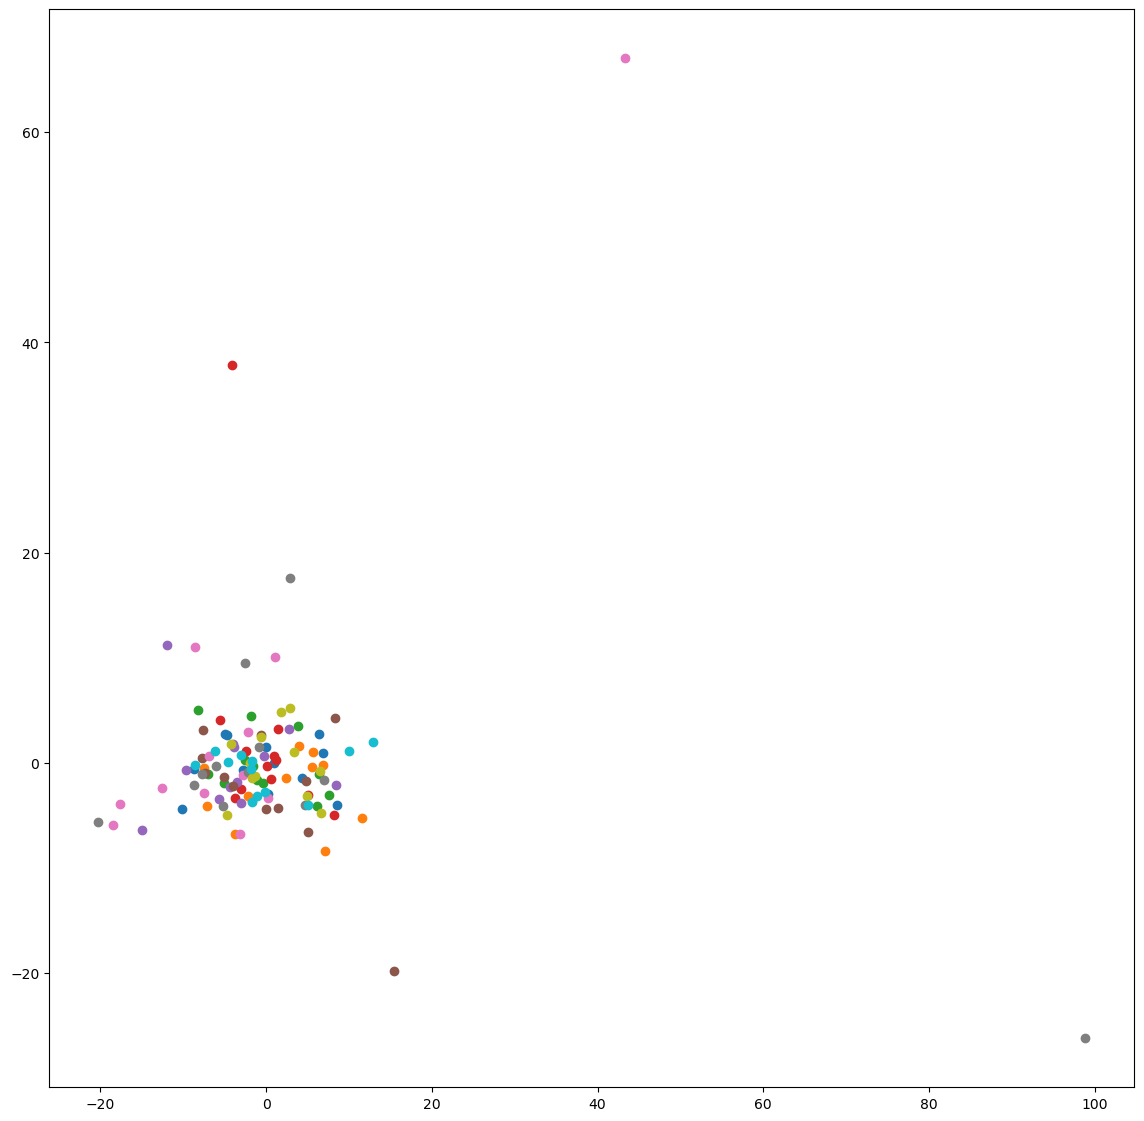

In [87]:
f, ax = plt.subplots(figsize=(14, 14))

for label in np.unique(pca_labels):
    idxs = np.where(pca_labels == label)[0]
    ax.scatter(pca_data_pca[idxs, 0], pca_data_pca[idxs, 1], label=label)